## Basis Size and Success Criteria

If we want to adjust how many first chapters are used or how many chapters a series must publish in order to be considered a success we can do so below.

In [22]:
# How many chapters we should consider when making the prediction.
basis_size=30

# The minimum number of chapters for a series to be considered a success.
success_criteria=50

# Loading Libraries

This project requires numerous Python libraries which are loaded below.

In [23]:
# We will obtain data from the SQlite database.
import sqlite3

# We will use functions we have previously created.
import sj_db_functions as dbfunc

# We will use the following for handling data and creating figures and charts.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# We use the following for preprocessing data and evaluating models.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score, GridSearchCV
from sklearn.feature_selection import RFECV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.base import clone

# We employ a suite of models to determine which may work best.
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# We use pickle to save the best model.
import pickle

# We set the seed for replicability.
np.random.seed(1)


# Obtaining Data

We will use data taken from our SQLite database. We can load modeling data easily using `dbfunc`.

In [24]:
connection=sqlite3.connect('shonen_jump.sqlite3')
cursor=connection.cursor()
cursor.execute("""SELECT MIN(release_date), MAX(release_date) FROM chapters;""")
date_range=cursor.fetchone()

In [25]:
print(f"When this notebook was last run the demo database contained chapters between {date_range[0]} and {date_range[1]}.")

When this notebook was last run the demo database contained chapters between 2022-01-16 and 2025-11-09.


In [26]:
simple=dbfunc.average_placements(connection, 20)

In [27]:
simple

,title,average_placement
0,Akane-banashi,7.60
1,Aliens Area,14.30
2,Astro Royale,11.05
3,Cipher Academy,12.25
4,Earthchild,12.90
5,Embers,15.35
6,Fabricant 100,13.40
7,Ginka & Glüna,12.85
8,Green Green Greens,13.00
9,Harukaze Mound,12.50


In [28]:
success=dbfunc.success_or_failure(connection,success_criteria=success_criteria,titles=simple['title'].to_list())

In [29]:
success

,title,success
0,Akane-banashi,1.0
1,Aliens Area,0.0
2,Astro Royale,1.0
3,Cipher Academy,1.0
4,Earthchild,0.0
5,Embers,0.0
6,Fabricant 100,0.0
7,Ginka & Glüna,0.0
8,Green Green Greens,0.0
9,Harukaze Mound,NaN


In [30]:
complex_data=dbfunc.load_modeling_data(connection,basis_size)

In [31]:
complex_data

,title,genre,one_creator,average_placement,color_pages,cover_pages,batch_size,place_chap_1,place_chap_2,place_chap_3,...,place_chap_23,place_chap_24,place_chap_25,place_chap_26,place_chap_27,place_chap_28,place_chap_29,place_chap_30,release_year,release_month
0,Akane-banashi,Other,0,7.266667,7.0,2,2,1,6,11,...,12,4,4,1,8,3,7,11,2022,2
1,Astro Royale,Battle,1,12.033333,6.0,1,3,1,4,11,...,9,6,18,19,14,9,20,16,2024,4
2,Cipher Academy,Other,0,13.433333,2.0,1,4,1,5,11,...,17,10,20,17,15,15,11,16,2022,11
3,Fabricant 100,Battle,1,14.966667,2.0,1,4,1,6,10,...,10,18,20,19,20,18,19,20,2022,12
4,Hima-Ten!,Romance,1,10.500000,6.0,1,3,1,4,7,...,16,16,17,15,10,15,11,13,2024,7
5,Ichi the Witch,Battle,0,6.733333,5.0,3,3,1,4,8,...,2,5,1,2,6,2,2,6,2024,9
6,Kagurabachi,Battle,1,11.766667,5.0,1,3,1,6,10,...,9,14,13,10,11,10,14,15,2023,9
7,Kill Blue,Comedy,1,7.566667,4.0,2,4,1,6,8,...,13,9,4,9,4,2,10,12,2023,4
8,Martial Master Asumi,Sports,1,13.633333,5.0,1,2,1,4,8,...,12,20,16,15,20,19,20,20,2023,6
9,Nue's Exorcist,Battle,1,10.400000,7.0,1,4,1,4,11,...,6,14,14,13,11,9,13,2,2023,5


In [32]:
success_column=dbfunc.success_or_failure(connection,success_criteria=success_criteria,titles=complex_data['title'].to_list())

In [33]:
# We close the connection now that we have obtained all the information from the database we need.
connection.close()

In [34]:
df=complex_data.merge(success_column,left_on='title',right_on='title')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 40 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              14 non-null     object 
 1   genre              14 non-null     object 
 2   one_creator        14 non-null     int64  
 3   average_placement  14 non-null     float64
 4   color_pages        14 non-null     float64
 5   cover_pages        14 non-null     int64  
 6   batch_size         14 non-null     int64  
 7   place_chap_1       14 non-null     int32  
 8   place_chap_2       14 non-null     int32  
 9   place_chap_3       14 non-null     int32  
 10  place_chap_4       14 non-null     int32  
 11  place_chap_5       14 non-null     int32  
 12  place_chap_6       14 non-null     int32  
 13  place_chap_7       14 non-null     int32  
 14  place_chap_8       14 non-null     int32  
 15  place_chap_9       14 non-null     int32  
 16  place_chap_10      14 non-nu

In [36]:
df.dropna(inplace=True)

In [37]:
X=df.drop(columns='success')
y=df['success']

# Loading a model

We can load a classifier from the corresponding folder using pickle.

In [38]:
with open('Demo_Classifier.pkl', 'rb') as f:
    loader = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: 'Demo_Classifier.pkl'

In [ ]:
loader

In [ ]:
trained_on=loader[1]['Trained On']
trained_on

['Shadow Eliminators',
 'Martial Master Asumi',
 'Psych House',
 "Ichigoki's Under Control!!",
 'Two on Ice',
 'Do Retry',
 'Shinobi Undercover',
 'Ultimate Exorcist Kiyoshi',
 'Aliens Area',
 'Kagurabachi',
 'Astro Royale',
 'Kaedegami',
 'Ice-Head Gill',
 'Ekiden Bros',
 'Hakutaku',
 'Kyokuto Necromance',
 'Tokyo Demon Bride Story',
 'Earthchild',
 'Nice Prison',
 "The Ichinose Family's Deadly Sins",
 'Syd Craft: Love Is a Mystery',
 'Fabricant 100',
 'Ping-Pong Peril',
 'Green Green Greens',
 'Ginka & Glüna',
 'Kill Blue',
 'MamaYuyu',
 'Akane-banashi',
 'Embers',
 'Cipher Academy',
 "Nue's Exorcist"]

In [ ]:
loaded_model=loader[0]

If we only want to consider the success of predictions on data the model hasn't been trained on we can cut down in advance.

In [ ]:
cut_down=df[~df['title'].isin(trained_on)].drop(columns=['success'])
cut_down

,title,genre,one_creator,average_placement,color_pages,release_date,batch_size,release_year,release_month
4,Dear Anemone,Battle,1,12.250000,1,2024-02-18,2,2024,2
13,Harukaze Mound,Sports,0,9.833333,2,2025-06-15,4,2025,6
14,Hima-Ten!,Romance,1,7.833333,2,2024-07-07,3,2024,7
16,Ichi the Witch,Battle,0,5.916667,3,2024-09-08,3,2024,9
18,Jujutsu Kaisen Modulo,Battle,0,6.200000,3,2025-09-07,2,2025,9
27,Otr of the Flame,Battle,1,11.166667,1,2025-05-11,2,2025,5
30,RuriDragon,Other,1,13.000000,2,2022-06-12,3,2022,6
33,Someone Hertz,Romance,1,7.000000,2,2025-09-14,2,2025,9
34,Star of Beethoven,Other,1,12.250000,1,2025-02-09,2,2025,2
35,Super Psychic Policeman Chojo,Comedy,1,6.583333,3,2024-02-11,2,2024,2


In [ ]:
loaded_model.predict(cut_down)

array([0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0], dtype=int64)

In [ ]:
loaded_model.score(cut_down,df[~df['title'].isin(trained_on)]['success'])

0.7692307692307693

In [39]:
complex_data.value_counts('cover_pages')

cover_pages
1    11
2     2
3     1
Name: count, dtype: int64

In [41]:
complex_data[complex_data['cover_pages']>=2]

,title,genre,one_creator,average_placement,color_pages,cover_pages,batch_size,place_chap_1,place_chap_2,place_chap_3,...,place_chap_23,place_chap_24,place_chap_25,place_chap_26,place_chap_27,place_chap_28,place_chap_29,place_chap_30,release_year,release_month
0,Akane-banashi,Other,0,7.266667,7.0,2,2,1,6,11,...,12,4,4,1,8,3,7,11,2022,2
5,Ichi the Witch,Battle,0,6.733333,5.0,3,3,1,4,8,...,2,5,1,2,6,2,2,6,2024,9
7,Kill Blue,Comedy,1,7.566667,4.0,2,4,1,6,8,...,13,9,4,9,4,2,10,12,2023,4


<Axes: xlabel='cover_pages', ylabel='count'>

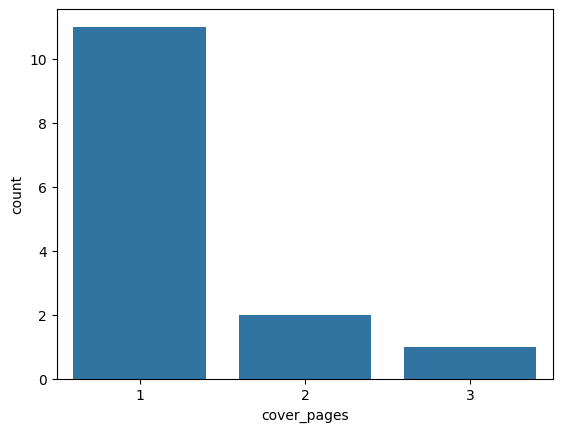

In [42]:
sns.countplot(complex_data,x='cover_pages')

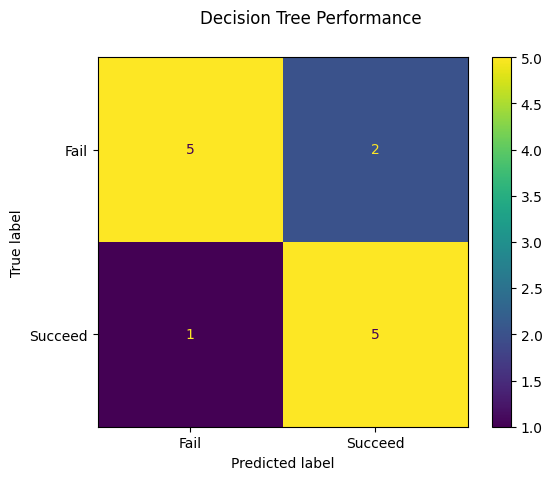

In [82]:
# Defining the matrix.
c_matrix = metrics.confusion_matrix([0,0,1,1,1,0,1,1,0,1,0,0,0], loaded_model.predict(cut_down), labels=[0,1])

# Setting the display options.
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = c_matrix, display_labels = ['Fail', 'Succeed'])
cm_display.plot()
# Adding a title.
plt.gcf().suptitle('Decision Tree Performance')
# Removing grid lines for clarity.
plt.grid(False)
plt.show()